# Split Strategy for Drone Detection Dataset

This notebook investigates dataset independence structure and freezes a reproducible train/validation/test manifest for the `drone-detection-and-classification-engine` project.

Scope constraints:

- Do not train a model.
- Do not implement a detector.
- Do not copy, move, delete, or edit source images/labels in `data/obj_det_base/`.
- Use lightweight, non-neural image similarity only.
- Create derived split manifests under `data/splits/`.

## 1. Setup and Configuration

In [1]:
from __future__ import annotations

import itertools
import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont, ImageOps

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.02,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
DATASET_RELATIVE_PATH = Path("data") / "obj_det_base"
FIGURE_RELATIVE_PATH = Path("reports") / "figures"
SPLIT_RELATIVE_PATH = Path("data") / "splits"


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / DATASET_RELATIVE_PATH).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find {DATASET_RELATIVE_PATH} from {start}")


PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / DATASET_RELATIVE_PATH
FIGURE_DIR = PROJECT_ROOT / FIGURE_RELATIVE_PATH
SPLIT_DIR = PROJECT_ROOT / SPLIT_RELATIVE_PATH
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATASET_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Split manifests: {SPLIT_DIR.relative_to(PROJECT_ROOT)}")

Project root: /Users/hardefarogonondo/Personal/Projects/Software/drone-detection-and-classification-engine
Dataset: data/obj_det_base
Figures: reports/figures
Split manifests: data/splits


In [2]:
def save_figure(fig: plt.Figure, name: str, *, dpi: int = 300, pdf: bool = True) -> None:
    png_path = FIGURE_DIR / f"{name}.png"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    if pdf:
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight", facecolor="white")
    print(f"saved: {png_path.relative_to(PROJECT_ROOT)}")


def display_df(df: pd.DataFrame, caption: str | None = None) -> None:
    if caption:
        display(Markdown(f"**{caption}**"))
    display(df)


def pct(value: float) -> str:
    return f"{100 * value:.2f}%"


def percentile_summary(series: pd.Series, percentiles=(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99)) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").dropna()
    out = pd.Series({"min": values.min()})
    q = values.quantile(percentiles)
    q.index = [f"p{int(p * 100):02d}" for p in percentiles]
    return pd.concat([out, q, pd.Series({"mean": values.mean(), "max": values.max()})])

## 2. Parse Dataset Metadata and Labels

This repeats the necessary parsing from `01_dataset_analysis.ipynb` so the split notebook is reproducible on its own.

In [3]:
FILENAME_RE = re.compile(
    r"^(?P<augmented>augmented_)?"
    r"raw_dataset_"
    r"(?P<scene_a>[A-Za-z]+)_(?P<weather_a>[A-Za-z]+)_"
    r"(?P<scene_b>[A-Za-z]+)_(?P<weather_b>[A-Za-z]+)_"
    r"(?P<capture_start>\d+)_(?P<capture_end>\d+)_"
    r"sequence\.(?P<sequence_index>\d+)_"
    r"step(?P<step>\d+)\.camera$"
)


def extract_filename_metadata(stem: str) -> dict:
    match = FILENAME_RE.match(stem)
    if not match:
        return {"metadata_parse_ok": False}
    parts = match.groupdict()
    scene_consistent = parts["scene_a"] == parts["scene_b"]
    weather_consistent = parts["weather_a"] == parts["weather_b"]
    scene = parts["scene_a"] if scene_consistent else pd.NA
    weather = parts["weather_a"] if weather_consistent else pd.NA
    scene_weather = f"{scene}_{weather}" if pd.notna(scene) and pd.notna(weather) else pd.NA
    capture_pair = f"{parts['capture_start']}_{parts['capture_end']}"
    canonical_raw_stem = stem.removeprefix("augmented_")
    frame_key = f"{scene_weather}__capture_{capture_pair}__sequence_{parts['sequence_index']}__step_{parts['step']}"
    return {
        "metadata_parse_ok": True,
        "raw_or_augmented": "augmented" if parts["augmented"] else "raw",
        "scene": scene,
        "weather": weather,
        "scene_weather": scene_weather,
        "scene_token_repeated_consistently": scene_consistent,
        "weather_token_repeated_consistently": weather_consistent,
        "capture_start": int(parts["capture_start"]),
        "capture_end": int(parts["capture_end"]),
        "capture_pair": capture_pair,
        "sequence_index": int(parts["sequence_index"]),
        "step": int(parts["step"]),
        "canonical_raw_stem": canonical_raw_stem,
        "scene_weather_capture_pair": f"{scene_weather}__capture_{capture_pair}",
        "frame_key": frame_key,
    }


def parse_label_file(label_path: Path, image_width: int, image_height: int) -> list[dict]:
    rows = []
    for line_number, raw_line in enumerate(label_path.read_text(encoding="utf-8", errors="replace").splitlines(), start=1):
        parts = raw_line.strip().split()
        if len(parts) != 5:
            raise ValueError(f"Malformed label line in {label_path.name}:{line_number}: {raw_line!r}")
        class_id = int(parts[0])
        x_center_norm, y_center_norm, width_norm, height_norm = [float(v) for v in parts[1:]]
        x_min_norm = x_center_norm - width_norm / 2
        y_min_norm = y_center_norm - height_norm / 2
        x_max_norm = x_center_norm + width_norm / 2
        y_max_norm = y_center_norm + height_norm / 2
        if any(v < 0 or v > 1 for v in [x_center_norm, y_center_norm, width_norm, height_norm]):
            raise ValueError(f"Normalized xywh out of range in {label_path.name}:{line_number}")
        if width_norm <= 0 or height_norm <= 0:
            raise ValueError(f"Zero/negative box size in {label_path.name}:{line_number}")
        if x_min_norm < 0 or y_min_norm < 0 or x_max_norm > 1 or y_max_norm > 1:
            raise ValueError(f"Box outside image in {label_path.name}:{line_number}")
        width_px = width_norm * image_width
        height_px = height_norm * image_height
        x_min_px = x_min_norm * image_width
        y_min_px = y_min_norm * image_height
        x_max_px = x_max_norm * image_width
        y_max_px = y_max_norm * image_height
        rows.append({
            "stem": label_path.stem,
            "label_file": label_path.name,
            "line_number": line_number,
            "class_id": class_id,
            "class_name": "drone" if class_id == 0 else f"class_{class_id}",
            "x_center_norm": x_center_norm,
            "y_center_norm": y_center_norm,
            "width_norm": width_norm,
            "height_norm": height_norm,
            "x_min_norm": x_min_norm,
            "y_min_norm": y_min_norm,
            "x_max_norm": x_max_norm,
            "y_max_norm": y_max_norm,
            "width_px": width_px,
            "height_px": height_px,
            "x_min_px": x_min_px,
            "y_min_px": y_min_px,
            "x_max_px": x_max_px,
            "y_max_px": y_max_px,
            "area_px": width_px * height_px,
            "relative_area": width_norm * height_norm,
            "bbox_aspect_ratio": width_norm / height_norm,
            "raw_line": raw_line,
        })
    return rows

In [4]:
image_paths = sorted([p for p in DATASET_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
label_paths = sorted([p for p in DATASET_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".txt"])
label_by_stem = {p.stem: p for p in label_paths}

image_rows = []
annotation_rows = []
for image_path in image_paths:
    with Image.open(image_path) as image:
        image.verify()
    with Image.open(image_path) as image:
        width, height = image.size
        mode = image.mode
        image_format = image.format
        alpha_extrema = image.getchannel("A").getextrema() if mode == "RGBA" else pd.NA
    label_path = label_by_stem.get(image_path.stem)
    if label_path is None:
        raise FileNotFoundError(f"Missing label for {image_path.name}")
    metadata = extract_filename_metadata(image_path.stem)
    image_rows.append({
        "stem": image_path.stem,
        "image_file": image_path.name,
        "label_file": label_path.name,
        "image_path": image_path,
        "label_path": label_path,
        "relative_image_path": str(image_path.relative_to(PROJECT_ROOT)),
        "relative_label_path": str(label_path.relative_to(PROJECT_ROOT)),
        "image_width": width,
        "image_height": height,
        "image_area_px": width * height,
        "aspect_ratio": width / height,
        "image_mode": mode,
        "image_format": image_format,
        "alpha_extrema": alpha_extrema,
        **metadata,
    })
    label_rows = parse_label_file(label_path, width, height)
    for row in label_rows:
        row.update({
            "image_file": image_path.name,
            "image_width": width,
            "image_height": height,
            "image_area_px": width * height,
            **metadata,
        })
        annotation_rows.append(row)

images_df = pd.DataFrame(image_rows).sort_values("stem").reset_index(drop=True)
annotations_df = pd.DataFrame(annotation_rows).sort_values(["stem", "line_number"]).reset_index(drop=True)
images_df["object_count"] = images_df["stem"].map(annotations_df.groupby("stem").size()).fillna(0).astype(int)
annotations_df["small_either_dim_lt_16px"] = (annotations_df["width_px"] < 16) | (annotations_df["height_px"] < 16)
annotations_df["small_either_dim_lt_32px"] = (annotations_df["width_px"] < 32) | (annotations_df["height_px"] < 32)
annotations_df["small_either_dim_lt_64px"] = (annotations_df["width_px"] < 64) | (annotations_df["height_px"] < 64)

inventory = pd.DataFrame([
    {"metric": "images", "value": len(images_df)},
    {"metric": "labels", "value": len(label_paths)},
    {"metric": "objects", "value": len(annotations_df)},
    {"metric": "classes", "value": annotations_df["class_id"].nunique()},
    {"metric": "unique capture_pair values", "value": images_df["capture_pair"].nunique()},
    {"metric": "unique frame keys", "value": images_df["frame_key"].nunique()},
])
display_df(inventory, "Parsed dataset inventory")
display_df(images_df["object_count"].value_counts().sort_index().rename_axis("objects_per_image").reset_index(name="image_count"), "Objects per image")

**Parsed dataset inventory**

,metric,value
0,images,2400
1,labels,2400
2,objects,4800
3,classes,1
4,unique capture_pair values,10
5,unique frame keys,2356


**Objects per image**

,objects_per_image,image_count
0,2,2400


## 3. Capture-Pair Semantics

The filename token `capture_pair` may encode two drone/source identities, but this section treats that as a hypothesis. Evidence comes from crop sheets and crop-size summaries, not from the token name alone.

In [5]:
def safe_font(size: int = 13) -> ImageFont.ImageFont:
    for candidate in ["Arial.ttf", "/System/Library/Fonts/Supplemental/Arial.ttf"]:
        try:
            return ImageFont.truetype(candidate, size)
        except Exception:
            pass
    return ImageFont.load_default()


def crop_with_context(image_path: Path, row: pd.Series, *, context: float = 2.5, output_size: int = 156) -> Image.Image:
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    box_w = row["x_max_px"] - row["x_min_px"]
    box_h = row["y_max_px"] - row["y_min_px"]
    cx = (row["x_min_px"] + row["x_max_px"]) / 2
    cy = (row["y_min_px"] + row["y_max_px"]) / 2
    side = max(box_w, box_h) * context
    side = max(side, 96)
    x0 = max(0, int(round(cx - side / 2)))
    y0 = max(0, int(round(cy - side / 2)))
    x1 = min(width, int(round(cx + side / 2)))
    y1 = min(height, int(round(cy + side / 2)))
    crop = image.crop((x0, y0, x1, y1))
    scale_x = output_size / max(1, crop.width)
    scale_y = output_size / max(1, crop.height)
    crop = crop.resize((output_size, output_size), Image.Resampling.LANCZOS)
    draw = ImageDraw.Draw(crop)
    bx0 = (row["x_min_px"] - x0) * scale_x
    by0 = (row["y_min_px"] - y0) * scale_y
    bx1 = (row["x_max_px"] - x0) * scale_x
    by1 = (row["y_max_px"] - y0) * scale_y
    draw.rectangle([bx0, by0, bx1, by1], outline=(255, 45, 85), width=2)
    return crop


def make_capture_pair_crop_sheet(capture_pair: str, *, output_size: int = 156, cols: int = 6) -> Path:
    selected_rows = []
    subset_images = images_df[images_df["capture_pair"] == capture_pair]
    for scene_weather in sorted(images_df["scene_weather"].dropna().unique()):
        candidates = subset_images[subset_images["scene_weather"] == scene_weather]
        if candidates.empty:
            continue
        # Pick a deterministic example near the median object area for this condition and include both objects.
        candidate_stems = candidates["stem"].tolist()
        candidate_ann = annotations_df[annotations_df["stem"].isin(candidate_stems)].copy()
        median_area = candidate_ann["area_px"].median()
        stem_scores = candidate_ann.groupby("stem")["area_px"].median().sub(median_area).abs().sort_values()
        chosen_stem = stem_scores.index[0]
        selected_rows.extend(annotations_df[annotations_df["stem"] == chosen_stem].sort_values("line_number").to_dict(orient="records"))

    if not selected_rows:
        raise ValueError(f"No annotation rows found for capture pair {capture_pair}")

    rows_n = math.ceil(len(selected_rows) / cols)
    label_h = 45
    title_h = 34
    panel_w = output_size
    panel_h = output_size + label_h
    sheet = Image.new("RGB", (cols * panel_w, title_h + rows_n * panel_h), "white")
    draw = ImageDraw.Draw(sheet)
    font = safe_font(12)
    title_font = safe_font(18)
    draw.text((8, 8), f"capture_pair {capture_pair}: drone crops across scene/weather", fill="black", font=title_font)

    for idx, row_dict in enumerate(selected_rows):
        row = pd.Series(row_dict)
        image_path = Path(images_df.loc[images_df["stem"] == row["stem"], "image_path"].iloc[0])
        crop = crop_with_context(image_path, row, output_size=output_size)
        col = idx % cols
        grid_row = idx // cols
        x = col * panel_w
        y = title_h + grid_row * panel_h
        sheet.paste(crop, (x, y))
        label = f"{row['scene_weather']} obj{int(row['line_number'])}"
        size_label = f"{row['width_px']:.0f}x{row['height_px']:.0f}px"
        draw.text((x + 4, y + output_size + 5), label, fill="black", font=font)
        draw.text((x + 4, y + output_size + 23), size_label, fill="#333333", font=font)

    output_path = FIGURE_DIR / f"capture_pair_{capture_pair}_crops.png"
    sheet.save(output_path)
    return output_path

capture_pair_crop_paths = []
for capture_pair in sorted(images_df["capture_pair"].unique(), key=lambda s: int(s.split("_")[0])):
    capture_pair_crop_paths.append(make_capture_pair_crop_sheet(capture_pair))

capture_pair_crop_df = pd.DataFrame({"capture_pair_crop_sheet": [str(p.relative_to(PROJECT_ROOT)) for p in capture_pair_crop_paths]})
display_df(capture_pair_crop_df, "Saved crop contact sheets")

**Saved crop contact sheets**

,capture_pair_crop_sheet
0,reports/figures/capture_pair_0_1_crops.png
1,reports/figures/capture_pair_2_3_crops.png
2,reports/figures/capture_pair_4_5_crops.png
3,reports/figures/capture_pair_6_7_crops.png
4,reports/figures/capture_pair_8_9_crops.png
5,reports/figures/capture_pair_10_11_crops.png
6,reports/figures/capture_pair_12_13_crops.png
7,reports/figures/capture_pair_14_15_crops.png
8,reports/figures/capture_pair_16_17_crops.png
9,reports/figures/capture_pair_18_19_crops.png


**Crop-size distribution by capture pair and object slot**

,capture_pair,line_number,objects,median_width_px,median_height_px,median_area_px,mean_area_px,pct_lt_32px
0,0_1,1,240,49.00096,51.99984,2299.502640,3922.415471,22.083333
1,0_1,2,240,57.99936,62.00064,3294.030400,4706.598543,12.500000
2,10_11,1,206,51.50080,47.99952,2406.028080,3473.752190,18.446602
3,10_11,2,206,68.99968,45.00000,3002.463360,3729.221222,17.475728
4,12_13,1,212,51.50080,35.00064,1635.988160,2542.986022,45.283019
5,12_13,2,212,49.99936,38.00016,1772.998720,2170.576273,48.113208
6,14_15,1,249,43.00032,31.99968,1320.019200,1671.047675,57.028112
7,14_15,2,249,49.00096,49.00032,2296.060320,3020.033921,18.875502
8,16_17,1,233,38.99904,38.99952,1259.960640,1984.861987,55.364807
9,16_17,2,233,46.99904,40.00032,1644.996479,2312.397186,35.193133


saved: reports/figures/capture_pair_bbox_size_distributions.png


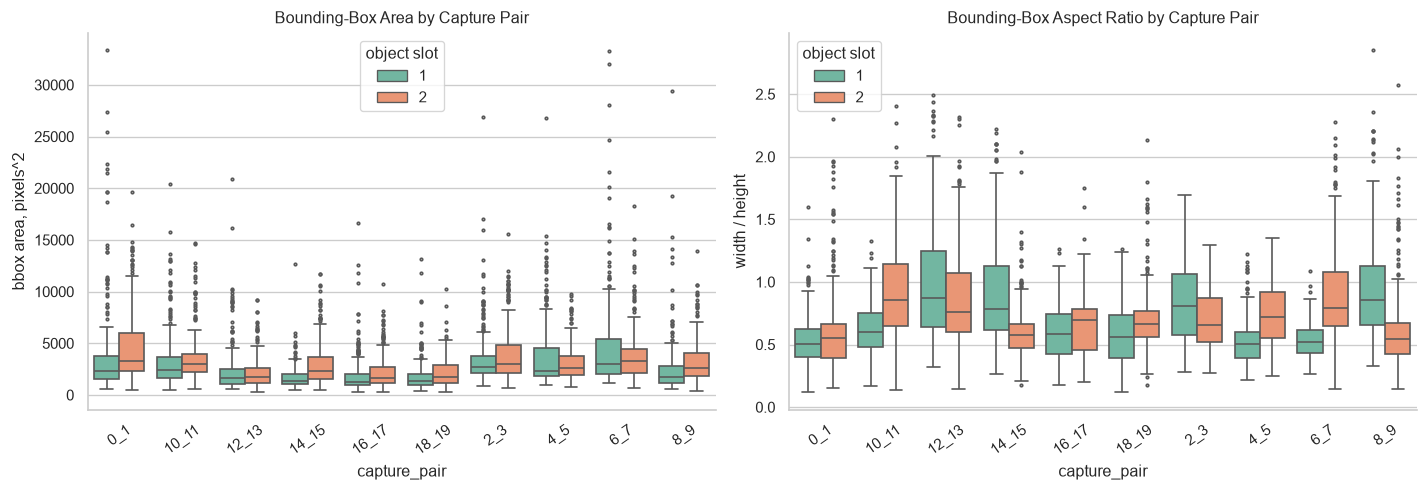

In [6]:
crop_size_summary = annotations_df.groupby(["capture_pair", "line_number"]).agg(
    objects=("stem", "count"),
    median_width_px=("width_px", "median"),
    median_height_px=("height_px", "median"),
    median_area_px=("area_px", "median"),
    mean_area_px=("area_px", "mean"),
    pct_lt_32px=("small_either_dim_lt_32px", lambda x: 100 * x.mean()),
).reset_index()

display_df(crop_size_summary, "Crop-size distribution by capture pair and object slot")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=annotations_df, x="capture_pair", y="area_px", hue="line_number", ax=axes[0], palette="Set2", fliersize=1.5)
axes[0].set_title("Bounding-Box Area by Capture Pair")
axes[0].set_xlabel("capture_pair")
axes[0].set_ylabel("bbox area, pixels^2")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="object slot")

sns.boxplot(data=annotations_df, x="capture_pair", y="bbox_aspect_ratio", hue="line_number", ax=axes[1], palette="Set2", fliersize=1.5)
axes[1].set_title("Bounding-Box Aspect Ratio by Capture Pair")
axes[1].set_xlabel("capture_pair")
axes[1].set_ylabel("width / height")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="object slot")
fig.tight_layout()
save_figure(fig, "capture_pair_bbox_size_distributions")
plt.show()

In [7]:
display(Markdown("""
**Observation versus hypothesis**

- Observed: each filename contains one of ten `capture_pair` values, and every image contains exactly two annotated drones.
- Observed: crop sheets saved above show the two object slots for each capture pair across city/forest/lake and sunny/foggy conditions.
- Observed: crop-size and aspect-ratio distributions vary by capture pair and by object slot.
- Hypothesis: `capture_pair` likely refers to the two drone/source identities or simulated targets present in an image.
- Consequence if the hypothesis is true: splitting the same capture pair across train and test would evaluate interpolation over already-seen target identities rather than stronger generalization to unseen target pairs.
"""))


**Observation versus hypothesis**

- Observed: each filename contains one of ten `capture_pair` values, and every image contains exactly two annotated drones.
- Observed: crop sheets saved above show the two object slots for each capture pair across city/forest/lake and sunny/foggy conditions.
- Observed: crop-size and aspect-ratio distributions vary by capture pair and by object slot.
- Hypothesis: `capture_pair` likely refers to the two drone/source identities or simulated targets present in an image.
- Consequence if the hypothesis is true: splitting the same capture pair across train and test would evaluate interpolation over already-seen target identities rather than stronger generalization to unseen target pairs.


## 4. Cross-Image Similarity and Near-Duplicate Analysis

This section uses downsampled grayscale fingerprints only. These are not neural embeddings and are not evidence of semantic identity by themselves.

In [8]:
def grayscale_fingerprint(path: Path, size=(64, 36)) -> np.ndarray:
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert("L").resize(size, Image.Resampling.BILINEAR)
        arr = np.asarray(image, dtype=np.float32) / 255.0
    flat = arr.reshape(-1)
    flat = flat - flat.mean()
    norm = np.linalg.norm(flat)
    if norm == 0:
        return flat
    return flat / norm

print("Building lightweight grayscale fingerprints...")
feature_matrix = np.stack([grayscale_fingerprint(Path(p)) for p in images_df["image_path"]]).astype(np.float32)
feature_stems = images_df["stem"].to_numpy()
stem_to_feature_index = {stem: idx for idx, stem in enumerate(feature_stems)}
print(feature_matrix.shape)

Building lightweight grayscale fingerprints...


(2400, 2304)


In [9]:
raw_mask = images_df["raw_or_augmented"].eq("raw").to_numpy()
aug_mask = images_df["raw_or_augmented"].eq("augmented").to_numpy()
raw_features = feature_matrix[raw_mask]
aug_features = feature_matrix[aug_mask]
raw_meta = images_df[raw_mask].reset_index(drop=True)
aug_meta = images_df[aug_mask].reset_index(drop=True)

# Since features are zero-mean and unit-norm, matrix multiplication gives normalized pixel correlation.
aug_raw_corr = aug_features @ raw_features.T
nearest_raw_idx = np.argmax(aug_raw_corr, axis=1)
nearest_raw_corr = aug_raw_corr[np.arange(len(aug_meta)), nearest_raw_idx]

nn_rows = []
raw_stem_set = set(raw_meta["stem"])
for aug_i, raw_i in enumerate(nearest_raw_idx):
    aug_row = aug_meta.iloc[aug_i]
    raw_row = raw_meta.iloc[int(raw_i)]
    exact_pair_raw_stem = aug_row["canonical_raw_stem"] if aug_row["canonical_raw_stem"] in raw_stem_set else pd.NA
    exact_pair_found = pd.notna(exact_pair_raw_stem)
    aug_label_text = Path(aug_row["label_path"]).read_text(encoding="utf-8", errors="replace")
    raw_label_text = Path(raw_row["label_path"]).read_text(encoding="utf-8", errors="replace")
    nn_rows.append({
        "augmented_stem": aug_row["stem"],
        "nearest_raw_stem": raw_row["stem"],
        "nearest_correlation": float(nearest_raw_corr[aug_i]),
        "nearest_same_scene_weather": aug_row["scene_weather"] == raw_row["scene_weather"],
        "nearest_same_capture_pair": aug_row["capture_pair"] == raw_row["capture_pair"],
        "nearest_same_sequence_index": aug_row["sequence_index"] == raw_row["sequence_index"],
        "nearest_same_frame_key": aug_row["frame_key"] == raw_row["frame_key"],
        "nearest_identical_label_text": aug_label_text == raw_label_text,
        "exact_filename_pair_exists": exact_pair_found,
        "exact_filename_pair_raw_stem": exact_pair_raw_stem,
        "nearest_is_exact_filename_pair": exact_pair_found and raw_row["stem"] == exact_pair_raw_stem,
    })

nearest_df = pd.DataFrame(nn_rows).sort_values("nearest_correlation", ascending=False).reset_index(drop=True)

display_df(nearest_df.head(20), "Strongest augmented-to-raw nearest neighbors")
display_df(nearest_df.tail(20), "Weakest augmented-to-raw nearest neighbors")

display_df(nearest_df[[
    "nearest_correlation",
    "nearest_same_scene_weather",
    "nearest_same_capture_pair",
    "nearest_same_sequence_index",
    "nearest_same_frame_key",
    "nearest_identical_label_text",
    "nearest_is_exact_filename_pair",
]].describe(include="all"), "Nearest-neighbor summary")

**Strongest augmented-to-raw nearest neighbors**

,augmented_stem,nearest_raw_stem,nearest_correlation,nearest_same_scene_weather,nearest_same_capture_pair,nearest_same_sequence_index,nearest_same_frame_key,nearest_identical_label_text,exact_filename_pair_exists,exact_filename_pair_raw_stem,nearest_is_exact_filename_pair
0,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_2_3_sequ...,0.988169,True,False,False,False,False,False,NaN,False
1,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.988068,True,False,False,False,False,False,NaN,False
2,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.987989,True,True,False,False,False,False,NaN,False
3,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_2_3_sequ...,0.987952,True,False,False,False,False,False,NaN,False
4,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.987944,True,False,False,False,False,False,NaN,False
5,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_2_3_sequ...,0.987838,True,False,False,False,False,False,NaN,False
6,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_2_3_sequ...,0.987833,True,False,False,False,False,False,NaN,False
7,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.987828,True,False,False,False,False,False,NaN,False
8,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.987802,True,False,False,False,False,False,NaN,False
9,augmented_raw_dataset_forest_foggy_forest_fogg...,raw_dataset_forest_foggy_forest_foggy_10_11_se...,0.987798,True,False,False,False,False,False,NaN,False


**Weakest augmented-to-raw nearest neighbors**

,augmented_stem,nearest_raw_stem,nearest_correlation,nearest_same_scene_weather,nearest_same_capture_pair,nearest_same_sequence_index,nearest_same_frame_key,nearest_identical_label_text,exact_filename_pair_exists,exact_filename_pair_raw_stem,nearest_is_exact_filename_pair
1180,augmented_raw_dataset_city_foggy_city_foggy_14...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.724853,False,False,False,False,False,False,NaN,False
1181,augmented_raw_dataset_city_foggy_city_foggy_16...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.724635,False,False,False,False,False,False,NaN,False
1182,augmented_raw_dataset_city_foggy_city_foggy_18...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.723612,False,False,False,False,False,False,NaN,False
1183,augmented_raw_dataset_city_foggy_city_foggy_8_...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.722728,False,False,False,False,False,False,NaN,False
1184,augmented_raw_dataset_city_foggy_city_foggy_12...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.722721,False,False,False,False,False,False,NaN,False
1185,augmented_raw_dataset_city_foggy_city_foggy_12...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.722710,False,False,False,False,False,False,NaN,False
1186,augmented_raw_dataset_city_foggy_city_foggy_8_...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.722470,False,False,False,False,False,False,NaN,False
1187,augmented_raw_dataset_city_foggy_city_foggy_18...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.722290,False,False,False,False,False,False,NaN,False
1188,augmented_raw_dataset_city_foggy_city_foggy_18...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.721781,False,False,False,False,False,False,NaN,False
1189,augmented_raw_dataset_city_foggy_city_foggy_4_...,raw_dataset_city_sunny_city_sunny_0_1_sequence...,0.721270,False,False,False,False,False,False,NaN,False


**Nearest-neighbor summary**

,nearest_correlation,nearest_same_scene_weather,nearest_same_capture_pair,nearest_same_sequence_index,nearest_same_frame_key,nearest_identical_label_text,nearest_is_exact_filename_pair
count,1200.000000,1200,1200,1200,1200,1200,1200
unique,NaN,2,2,2,2,2,2
top,NaN,True,False,False,False,False,False
freq,NaN,1017,1020,1189,1190,1190,1190
mean,0.900279,NaN,NaN,NaN,NaN,NaN,NaN
std,0.096251,NaN,NaN,NaN,NaN,NaN,NaN
min,0.711561,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.789344,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.946718,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.982873,NaN,NaN,NaN,NaN,NaN,NaN


**Augmented-to-raw nearest-neighbor counts**

,metric,value
0,augmented images,1200
1,exact filename pairs available,44
2,exact filename pairs recovered as nearest raw,10
3,nearest raw has same scene/weather,1017
4,nearest raw has same capture_pair,180
5,nearest raw has identical label text,10


**Correlation distribution among augmented images with exact filename pairs**

,exact-pair-nearest-correlation
count,44.000000
mean,0.888591
std,0.096824
min,0.725810
1%,0.728452
5%,0.738135
25%,0.789494
50%,0.942780
75%,0.983194
95%,0.987329


saved: reports/figures/nearest_raw_similarity_distribution.png


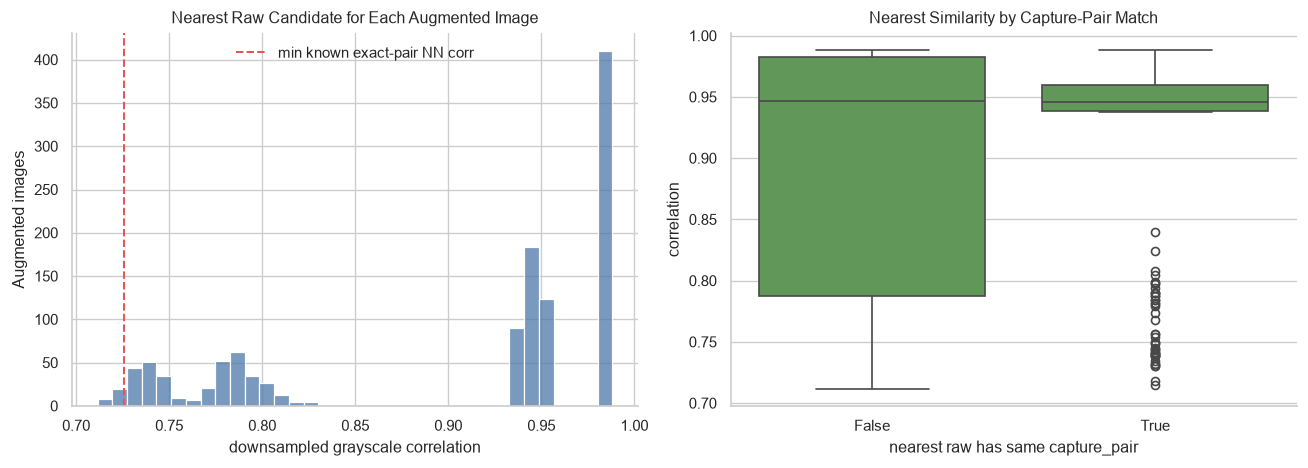

In [10]:
known_exact_pair_df = nearest_df[nearest_df["exact_filename_pair_exists"]].copy()
non_exact_aug_df = nearest_df[~nearest_df["exact_filename_pair_exists"]].copy()

pair_counts = pd.DataFrame([
    {"metric": "augmented images", "value": len(nearest_df)},
    {"metric": "exact filename pairs available", "value": int(nearest_df["exact_filename_pair_exists"].sum())},
    {"metric": "exact filename pairs recovered as nearest raw", "value": int(nearest_df["nearest_is_exact_filename_pair"].sum())},
    {"metric": "nearest raw has same scene/weather", "value": int(nearest_df["nearest_same_scene_weather"].sum())},
    {"metric": "nearest raw has same capture_pair", "value": int(nearest_df["nearest_same_capture_pair"].sum())},
    {"metric": "nearest raw has identical label text", "value": int(nearest_df["nearest_identical_label_text"].sum())},
])
display_df(pair_counts, "Augmented-to-raw nearest-neighbor counts")

if len(known_exact_pair_df):
    display_df(known_exact_pair_df["nearest_correlation"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("exact-pair-nearest-correlation"), "Correlation distribution among augmented images with exact filename pairs")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
sns.histplot(nearest_df["nearest_correlation"], bins=35, ax=axes[0], color="#4C78A8", edgecolor="white")
axes[0].set_title("Nearest Raw Candidate for Each Augmented Image")
axes[0].set_xlabel("downsampled grayscale correlation")
axes[0].set_ylabel("Augmented images")
if len(known_exact_pair_df):
    axes[0].axvline(known_exact_pair_df["nearest_correlation"].min(), color="#E45756", linestyle="--", label="min known exact-pair NN corr")
    axes[0].legend(frameon=False)

sns.boxplot(data=nearest_df, x="nearest_same_capture_pair", y="nearest_correlation", ax=axes[1], color="#59A14F")
axes[1].set_title("Nearest Similarity by Capture-Pair Match")
axes[1].set_xlabel("nearest raw has same capture_pair")
axes[1].set_ylabel("correlation")
fig.tight_layout()
save_figure(fig, "nearest_raw_similarity_distribution")
plt.show()

saved: reports/figures/nearest_raw_strongest_matches.png


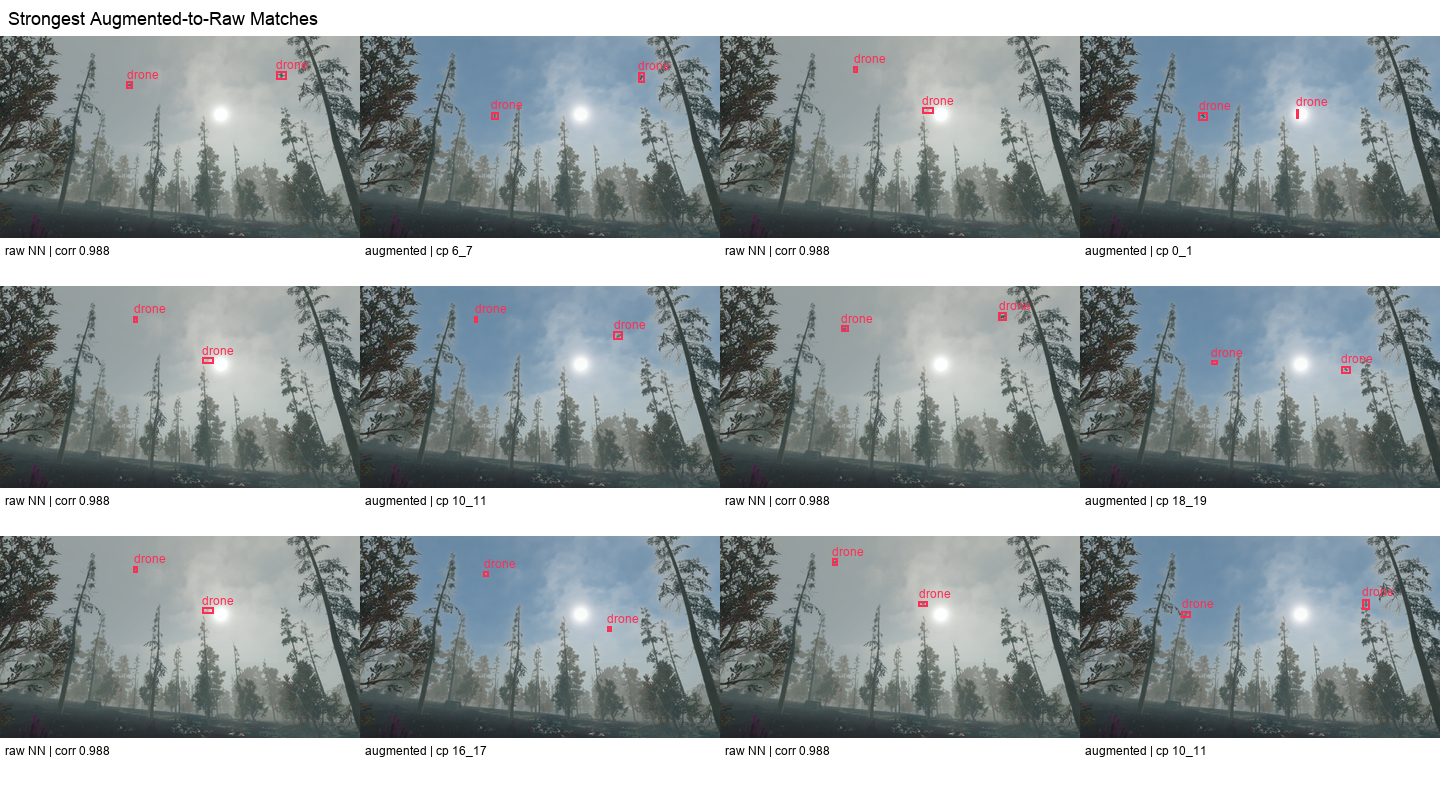

saved: reports/figures/nearest_raw_borderline_matches.png


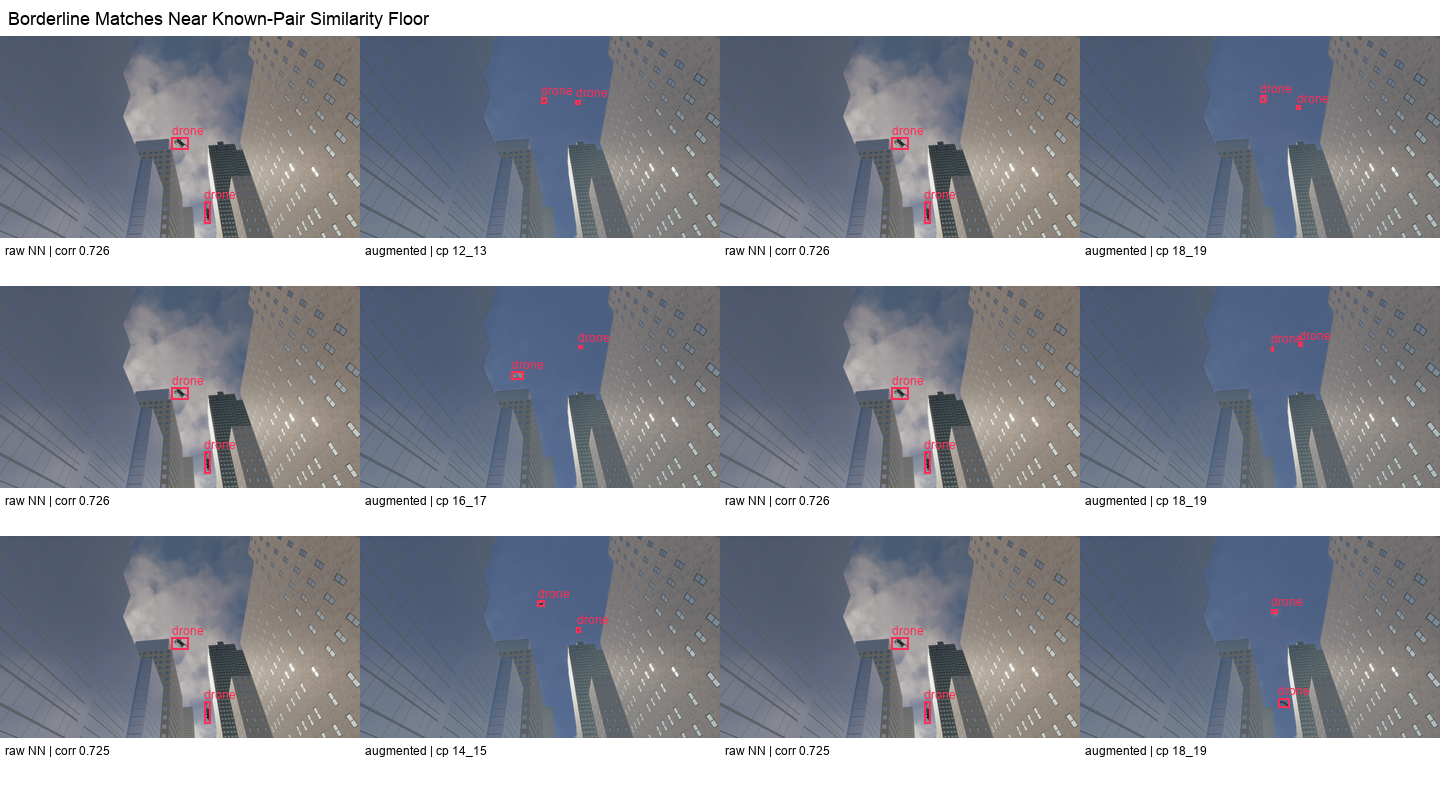

PosixPath('/Users/hardefarogonondo/Personal/Projects/Software/drone-detection-and-classification-engine/reports/figures/nearest_raw_borderline_matches.png')

In [11]:
def annotated_panel(stem: str, *, width: int = 360, label: str = "") -> Image.Image:
    img_row = images_df.loc[images_df["stem"] == stem].iloc[0]
    image = Image.open(Path(img_row["image_path"])).convert("RGB")
    original_w, original_h = image.size
    height = int(round(original_h * width / original_w))
    image = image.resize((width, height), Image.Resampling.LANCZOS)
    draw = ImageDraw.Draw(image)
    font = safe_font(12)
    sx = width / original_w
    sy = height / original_h
    for _, box in annotations_df[annotations_df["stem"] == stem].iterrows():
        coords = [box["x_min_px"] * sx, box["y_min_px"] * sy, box["x_max_px"] * sx, box["y_max_px"] * sy]
        draw.rectangle(coords, outline=(255, 45, 85), width=2)
        draw.text((coords[0], max(0, coords[1] - 14)), "drone", fill=(255, 45, 85), font=font)
    label_h = 48
    canvas = Image.new("RGB", (width, height + label_h), "white")
    canvas.paste(image, (0, 0))
    draw = ImageDraw.Draw(canvas)
    draw.text((5, height + 6), label[:80], fill="black", font=font)
    return canvas


def make_pair_grid(pair_rows: pd.DataFrame, output_name: str, title: str, *, max_pairs: int = 6) -> Path:
    pair_rows = pair_rows.head(max_pairs).reset_index(drop=True)
    panels = []
    for _, row in pair_rows.iterrows():
        aug_stem = row["augmented_stem"]
        raw_stem = row["nearest_raw_stem"]
        corr = row["nearest_correlation"]
        panels.append(annotated_panel(raw_stem, label=f"raw NN | corr {corr:.3f}"))
        panels.append(annotated_panel(aug_stem, label=f"augmented | cp {images_df.loc[images_df['stem'] == aug_stem, 'capture_pair'].iloc[0]}"))
    cols = 4
    rows_n = math.ceil(len(panels) / cols)
    panel_w = max(p.width for p in panels)
    panel_h = max(p.height for p in panels)
    title_h = 36
    sheet = Image.new("RGB", (cols * panel_w, title_h + rows_n * panel_h), "white")
    draw = ImageDraw.Draw(sheet)
    draw.text((8, 8), title, fill="black", font=safe_font(18))
    for idx, panel in enumerate(panels):
        x = (idx % cols) * panel_w
        y = title_h + (idx // cols) * panel_h
        sheet.paste(panel, (x, y))
    output_path = FIGURE_DIR / f"{output_name}.png"
    sheet.save(output_path)
    print(f"saved: {output_path.relative_to(PROJECT_ROOT)}")
    display(sheet)
    return output_path

strongest_matches = nearest_df.sort_values("nearest_correlation", ascending=False)
if len(known_exact_pair_df):
    borderline_value = known_exact_pair_df["nearest_correlation"].min()
    borderline_matches = nearest_df.iloc[(nearest_df["nearest_correlation"] - borderline_value).abs().sort_values().index].head(6)
else:
    borderline_value = nearest_df["nearest_correlation"].quantile(0.95)
    borderline_matches = nearest_df.iloc[(nearest_df["nearest_correlation"] - borderline_value).abs().sort_values().index].head(6)

make_pair_grid(strongest_matches, "nearest_raw_strongest_matches", "Strongest Augmented-to-Raw Matches", max_pairs=6)
make_pair_grid(borderline_matches, "nearest_raw_borderline_matches", "Borderline Matches Near Known-Pair Similarity Floor", max_pairs=6)

## 5. Background / Sequence Similarity

This section asks whether metadata-defined neighborhoods are visually closer than cross-group samples. The feature remains the same lightweight grayscale fingerprint.

In [12]:
full_corr = feature_matrix @ feature_matrix.T
rng = np.random.default_rng(SEED)
n_images = len(images_df)

pair_i = rng.integers(0, n_images, size=80000)
pair_j = rng.integers(0, n_images, size=80000)
mask = pair_i != pair_j
pair_i = pair_i[mask]
pair_j = pair_j[mask]

sampled_pairs = pd.DataFrame({
    "i": pair_i,
    "j": pair_j,
    "correlation": full_corr[pair_i, pair_j],
})
for column in ["capture_pair", "scene_weather", "scene_weather_capture_pair", "frame_key", "raw_or_augmented"]:
    values = images_df[column].to_numpy()
    sampled_pairs[f"same_{column}"] = values[pair_i] == values[pair_j]

sequence_values = images_df["sequence_index"].to_numpy()
sampled_pairs["sequence_distance"] = np.abs(sequence_values[pair_i] - sequence_values[pair_j])
sampled_pairs["neighboring_sequence_index"] = sampled_pairs["same_scene_weather_capture_pair"] & (sampled_pairs["sequence_distance"] <= 5)

similarity_categories = []
category_masks = {
    "same frame_key": sampled_pairs["same_frame_key"],
    "same scene_weather + capture_pair": sampled_pairs["same_scene_weather_capture_pair"],
    "same capture_pair": sampled_pairs["same_capture_pair"],
    "same scene_weather": sampled_pairs["same_scene_weather"],
    "neighbor seq <=5 within group": sampled_pairs["neighboring_sequence_index"],
    "different scene_weather and capture_pair": (~sampled_pairs["same_scene_weather"]) & (~sampled_pairs["same_capture_pair"]),
}
for name, mask_values in category_masks.items():
    values = sampled_pairs.loc[mask_values, "correlation"]
    if len(values):
        similarity_categories.append({
            "category": name,
            "pairs_sampled": len(values),
            "median_corr": values.median(),
            "mean_corr": values.mean(),
            "p05_corr": values.quantile(0.05),
            "p95_corr": values.quantile(0.95),
        })

similarity_category_df = pd.DataFrame(similarity_categories).sort_values("median_corr", ascending=False)
display_df(similarity_category_df, "Sampled pairwise similarity by metadata relationship")

**Sampled pairwise similarity by metadata relationship**

,category,pairs_sampled,median_corr,mean_corr,p05_corr,p95_corr
3,same scene_weather,13314,0.987987,0.943927,0.662836,0.999920
1,same scene_weather + capture_pair,1308,0.987339,0.941545,0.661567,0.999921
4,neighbor seq <=5 within group,13,0.982856,0.914695,0.722342,0.999971
0,same frame_key,1,0.753906,0.753906,0.753906,0.753906
2,same capture_pair,7957,0.488778,0.392954,-0.196745,0.999169
5,different scene_weather and capture_pair,60002,0.156539,0.283281,-0.211023,0.961378


**Adjacent-by-sequence similarity inside proposed groups**

,adjacent_sequence_correlation
count,2340.000000
mean,0.939558
std,0.106298
min,0.617331
1%,0.633408
5%,0.652614
25%,0.943192
50%,0.987550
75%,0.999781
95%,0.999965


saved: reports/figures/metadata_similarity_relationships.png


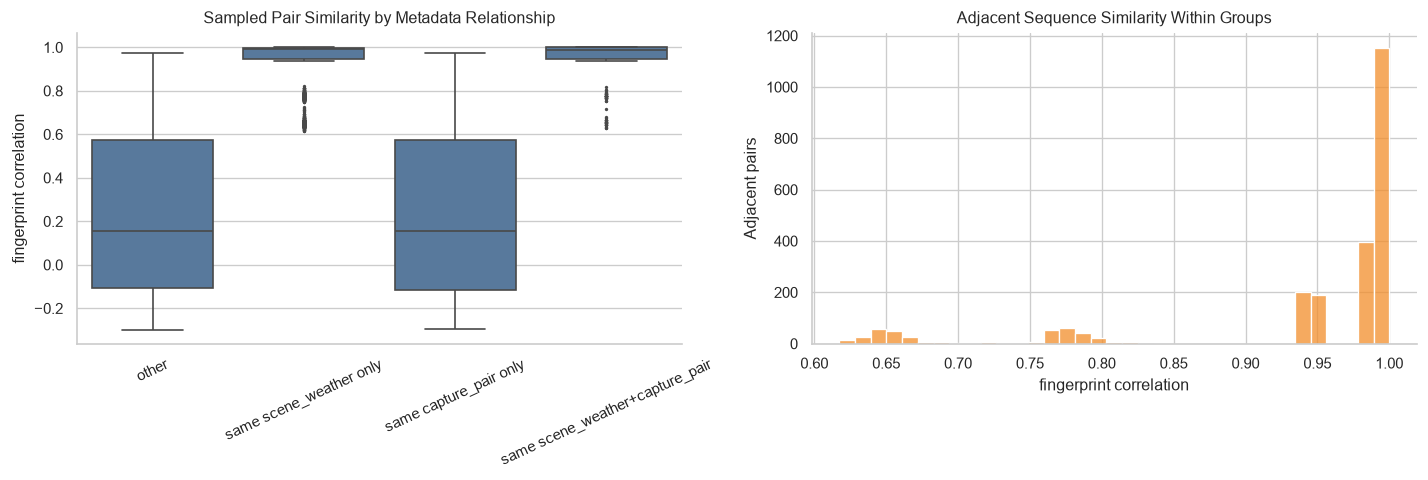

In [13]:
# Adjacent frames after sorting by sequence_index inside scene_weather + capture_pair.
adjacent_rows = []
for group_key, group in images_df.sort_values("sequence_index").groupby("scene_weather_capture_pair"):
    indices = group.index.to_numpy()
    if len(indices) < 2:
        continue
    for a, b in zip(indices[:-1], indices[1:]):
        adjacent_rows.append({
            "scene_weather_capture_pair": group_key,
            "sequence_distance": abs(int(images_df.loc[a, "sequence_index"]) - int(images_df.loc[b, "sequence_index"])),
            "correlation": float(full_corr[a, b]),
        })
adjacent_df = pd.DataFrame(adjacent_rows)

display_df(adjacent_df["correlation"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("adjacent_sequence_correlation"), "Adjacent-by-sequence similarity inside proposed groups")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))
plot_df = sampled_pairs.copy()
plot_df["relationship"] = np.select(
    [
        plot_df["same_scene_weather_capture_pair"],
        plot_df["same_capture_pair"],
        plot_df["same_scene_weather"],
    ],
    ["same scene_weather+capture_pair", "same capture_pair only", "same scene_weather only"],
    default="other",
)
sns.boxplot(data=plot_df.sample(min(20000, len(plot_df)), random_state=SEED), x="relationship", y="correlation", ax=axes[0], color="#4C78A8", fliersize=1)
axes[0].set_title("Sampled Pair Similarity by Metadata Relationship")
axes[0].set_xlabel("")
axes[0].set_ylabel("fingerprint correlation")
axes[0].tick_params(axis="x", rotation=25)

sns.histplot(adjacent_df["correlation"], bins=35, ax=axes[1], color="#F28E2B", edgecolor="white")
axes[1].set_title("Adjacent Sequence Similarity Within Groups")
axes[1].set_xlabel("fingerprint correlation")
axes[1].set_ylabel("Adjacent pairs")
fig.tight_layout()
save_figure(fig, "metadata_similarity_relationships")
plt.show()

## 6. Candidate Split Strategies

A good split should avoid leakage while preserving enough balance to make evaluation interpretable.

In [14]:
def make_random_image_split(seed: int = SEED) -> pd.Series:
    rng = np.random.default_rng(seed)
    shuffled = np.array(images_df["stem"])
    rng.shuffle(shuffled)
    n = len(shuffled)
    train_end = int(round(0.70 * n))
    val_end = train_end + int(round(0.15 * n))
    assignment = {}
    for stem in shuffled[:train_end]:
        assignment[stem] = "train"
    for stem in shuffled[train_end:val_end]:
        assignment[stem] = "val"
    for stem in shuffled[val_end:]:
        assignment[stem] = "test"
    return images_df["stem"].map(assignment)


def assign_groups_to_splits(group_column: str, target=(0.70, 0.15, 0.15), seed: int = SEED) -> pd.Series:
    groups = sorted(images_df[group_column].dropna().unique().tolist())
    rng = np.random.default_rng(seed)
    shuffled_groups = groups.copy()
    rng.shuffle(shuffled_groups)
    group_counts = images_df[group_column].value_counts().to_dict()
    target_counts = {"train": target[0] * len(images_df), "val": target[1] * len(images_df), "test": target[2] * len(images_df)}
    split_counts = {"train": 0, "val": 0, "test": 0}
    group_assignment = {}
    for group in sorted(shuffled_groups, key=lambda g: group_counts[g], reverse=True):
        best_split = min(["train", "val", "test"], key=lambda split: (split_counts[split] + group_counts[group] - target_counts[split]) / target_counts[split])
        # The key above can overfill early; use absolute proportional deficit for robustness.
        best_split = max(["train", "val", "test"], key=lambda split: target_counts[split] - split_counts[split])
        group_assignment[group] = best_split
        split_counts[best_split] += group_counts[group]
    return images_df[group_column].map(group_assignment)


def exact_frame_key_split(seed: int = SEED) -> pd.Series:
    return assign_groups_to_splits("frame_key", seed=seed)


def scene_weather_capture_split(seed: int = SEED) -> pd.Series:
    return assign_groups_to_splits("scene_weather_capture_pair", seed=seed)


def count_cross_split_groups(split_series: pd.Series, group_column: str) -> int:
    tmp = images_df[[group_column]].copy()
    tmp["split"] = split_series.values
    return int(tmp.groupby(group_column)["split"].nunique().gt(1).sum())


def exact_pair_crossings(split_series: pd.Series) -> int:
    split_by_stem = dict(zip(images_df["stem"], split_series))
    crossings = 0
    for _, row in nearest_df[nearest_df["exact_filename_pair_exists"]].iterrows():
        aug_split = split_by_stem[row["augmented_stem"]]
        raw_split = split_by_stem[row["exact_filename_pair_raw_stem"]]
        crossings += int(aug_split != raw_split)
    return crossings


def strategy_summary(name: str, split_series: pd.Series, group_column: str | None, description: str) -> dict:
    split_counts = split_series.value_counts().to_dict()
    forbidden_column = group_column if group_column else "none"
    return {
        "strategy": name,
        "description": description,
        "group_column": forbidden_column,
        "groups": images_df[group_column].nunique() if group_column else len(images_df),
        "train_images": split_counts.get("train", 0),
        "val_images": split_counts.get("val", 0),
        "test_images": split_counts.get("test", 0),
        "capture_pair_cross_split_groups": count_cross_split_groups(split_series, "capture_pair"),
        "scene_weather_capture_pair_cross_split_groups": count_cross_split_groups(split_series, "scene_weather_capture_pair"),
        "frame_key_cross_split_groups": count_cross_split_groups(split_series, "frame_key"),
        "exact_raw_aug_pair_crossings": exact_pair_crossings(split_series),
    }

random_split = make_random_image_split()
frame_split = exact_frame_key_split()
scene_weather_capture_pair_split = scene_weather_capture_split()

In [15]:
def score_capture_pair_assignment(assignments: dict[str, str]) -> tuple[float, dict]:
    split_series = images_df["capture_pair"].map(assignments)
    split_counts = split_series.value_counts().reindex(["train", "val", "test"], fill_value=0)
    total = len(images_df)
    target_props = pd.Series({"train": 0.70, "val": 0.15, "test": 0.15})
    count_penalty = (split_counts / total - target_props).abs().sum()

    global_scene = images_df["scene_weather"].value_counts(normalize=True).sort_index()
    global_source = images_df["raw_or_augmented"].value_counts(normalize=True).sort_index()
    global_small = annotations_df["small_either_dim_lt_32px"].mean()
    global_width_median = annotations_df["width_px"].median()
    global_height_median = annotations_df["height_px"].median()
    global_area_median = annotations_df["area_px"].median()

    tmp = images_df[["stem", "scene_weather", "raw_or_augmented"]].copy()
    tmp["split"] = split_series.values

    scene_penalty = 0.0
    source_penalty = 0.0
    size_penalty = 0.0
    median_penalty = 0.0
    coverage_penalty = 0.0

    for split in ["train", "val", "test"]:
        split_tmp = tmp[tmp["split"] == split]
        if split_tmp.empty:
            coverage_penalty += 100
            continue

        scene_props = split_tmp["scene_weather"].value_counts(normalize=True).reindex(global_scene.index, fill_value=0).sort_index()
        source_props = split_tmp["raw_or_augmented"].value_counts(normalize=True).reindex(global_source.index, fill_value=0).sort_index()
        split_ann = annotations_df[annotations_df["stem"].isin(split_tmp["stem"])]

        scene_penalty += (scene_props - global_scene).abs().sum()
        source_penalty += (source_props - global_source).abs().sum()
        size_penalty += abs(split_ann["small_either_dim_lt_32px"].mean() - global_small)
        median_penalty += abs(split_ann["width_px"].median() / global_width_median - 1)
        median_penalty += abs(split_ann["height_px"].median() / global_height_median - 1)
        median_penalty += abs(split_ann["area_px"].median() / global_area_median - 1)

        if (scene_props == 0).any():
            coverage_penalty += 10
        if (source_props == 0).any():
            coverage_penalty += 10

    # Only ten capture-pair groups are available. This score keeps the split near 70/15/15
    # while giving substantial weight to object-size balance, since small-object detection is central here.
    test_stability_bonus = -0.00005 * split_counts["test"]
    score = (
        8 * count_penalty
        + scene_penalty
        + source_penalty
        + 8 * size_penalty
        + 0.5 * median_penalty
        + coverage_penalty
        + test_stability_bonus
    )
    parts = {
        "count_penalty": count_penalty,
        "scene_penalty": scene_penalty,
        "source_penalty": source_penalty,
        "size_penalty": size_penalty,
        "median_penalty": median_penalty,
        "coverage_penalty": coverage_penalty,
        "test_stability_bonus": test_stability_bonus,
    }
    return score, parts

capture_pairs = sorted(images_df["capture_pair"].unique(), key=lambda s: int(s.split("_")[0]))
best_assignment = None
best_score = float("inf")
best_parts = None

# With 10 capture-pair groups, exact 70/15/15 is impossible. We evaluate the closest
# practical holdout layouts: 7 train groups with either 1 or 2 validation groups.
for train_groups in itertools.combinations(capture_pairs, 7):
    remaining_after_train = [g for g in capture_pairs if g not in train_groups]
    for val_group_count in [1, 2]:
        for val_groups in itertools.combinations(remaining_after_train, val_group_count):
            test_groups = [g for g in remaining_after_train if g not in val_groups]
            assignments = {g: "train" for g in train_groups}
            assignments.update({g: "val" for g in val_groups})
            assignments.update({g: "test" for g in test_groups})
            score, parts = score_capture_pair_assignment(assignments)
            if score < best_score:
                best_score = score
                best_assignment = assignments
                best_parts = parts

capture_pair_split = images_df["capture_pair"].map(best_assignment)

selected_groups_df = pd.DataFrame([
    {"capture_pair": group, "split": split, "image_count": int((images_df["capture_pair"] == group).sum())}
    for group, split in sorted(best_assignment.items(), key=lambda item: int(item[0].split("_")[0]))
])

display_df(selected_groups_df, "Optimized capture-pair holdout assignment")
display_df(pd.DataFrame([{"score": best_score, **best_parts}]), "Capture-pair assignment score components")

**Optimized capture-pair holdout assignment**

,capture_pair,split,image_count
0,0_1,train,240
1,2_3,test,247
2,4_5,train,243
3,6_7,train,276
4,8_9,val,245
5,10_11,train,206
6,12_13,test,212
7,14_15,train,249
8,16_17,train,233
9,18_19,train,249


**Capture-pair assignment score components**

,score,count_penalty,scene_penalty,source_penalty,size_penalty,median_penalty,coverage_penalty,test_stability_bonus
0,1.764072,0.095833,0.217521,0.038928,0.077993,0.279924,0.0,-0.02295


In [16]:
strategy_rows = [
    strategy_summary("naive random image split", random_split, None, "Random individual images; high risk for grouped synthetic data."),
    strategy_summary("exact frame-key grouping", frame_split, "frame_key", "Keeps exact raw/aug frame-key pairs together only."),
    strategy_summary("scene_weather + capture_pair grouping", scene_weather_capture_pair_split, "scene_weather_capture_pair", "Keeps each scene/weather/capture-pair group together."),
    strategy_summary("capture_pair grouping", capture_pair_split, "capture_pair", "Holds out entire capture pairs across all scenes/weather."),
]
strategy_df = pd.DataFrame(strategy_rows)
display_df(strategy_df, "Candidate split strategy comparison")

display(Markdown("""
**Strategy interpretation**

- Naive random image splitting gives convenient ratios but allows frame keys, capture pairs, and scene/weather/capture groups to cross splits.
- Exact frame-key grouping fixes only the 44 exact raw/augmented filename-pair cases and leaves broader capture/source leakage unresolved.
- `scene_weather + capture_pair` grouping blocks within-condition leakage but still allows the same capture pair to appear in train and test under different conditions.
- `capture_pair` grouping is stricter: if capture pairs correspond to drone/source identities, test data measures generalization to held-out target pairs across already-seen scene/weather families.
"""))

**Candidate split strategy comparison**

,strategy,description,group_column,groups,train_images,val_images,test_images,capture_pair_cross_split_groups,scene_weather_capture_pair_cross_split_groups,frame_key_cross_split_groups,exact_raw_aug_pair_crossings
0,naive random image split,Random individual images; high risk for groupe...,none,2400,1680,360,360,10,60,23,23
1,exact frame-key grouping,Keeps exact raw/aug frame-key pairs together o...,frame_key,2356,1680,360,360,10,60,0,0
2,scene_weather + capture_pair grouping,Keeps each scene/weather/capture-pair group to...,scene_weather_capture_pair,60,1696,352,352,8,0,0,0
3,capture_pair grouping,Holds out entire capture pairs across all scen...,capture_pair,10,1696,245,459,0,0,0,0



**Strategy interpretation**

- Naive random image splitting gives convenient ratios but allows frame keys, capture pairs, and scene/weather/capture groups to cross splits.
- Exact frame-key grouping fixes only the 44 exact raw/augmented filename-pair cases and leaves broader capture/source leakage unresolved.
- `scene_weather + capture_pair` grouping blocks within-condition leakage but still allows the same capture pair to appear in train and test under different conditions.
- `capture_pair` grouping is stricter: if capture pairs correspond to drone/source identities, test data measures generalization to held-out target pairs across already-seen scene/weather families.


## 7. Select and Freeze the Final Split

Selected strategy: deterministic capture-pair grouping.

Rationale: crop sheets and metadata structure make `capture_pair` the strongest available proxy for drone/source identity. Holding out entire capture pairs is more defensible than allowing possible target identities to appear in multiple splits.

In [17]:
FINAL_GROUP_COLUMN = "capture_pair"
FINAL_GROUPING_DESCRIPTION = "capture_pair holdout"

manifest_df = images_df.copy()
manifest_df["split"] = capture_pair_split.values
manifest_df["grouping_key_used"] = manifest_df[FINAL_GROUP_COLUMN]
manifest_df["grouping_strategy"] = FINAL_GROUPING_DESCRIPTION
manifest_df["object_count"] = manifest_df["object_count"].astype(int)

# Add per-image box summaries for downstream sanity checks.
per_image_box = annotations_df.groupby("stem").agg(
    median_box_width_px=("width_px", "median"),
    median_box_height_px=("height_px", "median"),
    median_box_area_px=("area_px", "median"),
    mean_relative_area=("relative_area", "mean"),
    objects_lt_32px=("small_either_dim_lt_32px", "sum"),
).reset_index()
manifest_df = manifest_df.merge(per_image_box, on="stem", how="left")

manifest_columns = [
    "stem", "image_file", "label_file", "relative_image_path", "relative_label_path",
    "split", "scene", "weather", "scene_weather", "capture_pair", "sequence_index", "step",
    "raw_or_augmented", "frame_key", "grouping_strategy", "grouping_key_used", "object_count",
    "image_width", "image_height", "image_mode", "median_box_width_px", "median_box_height_px",
    "median_box_area_px", "mean_relative_area", "objects_lt_32px",
]
manifest_df = manifest_df[manifest_columns].sort_values(["split", "capture_pair", "scene_weather", "sequence_index", "raw_or_augmented", "stem"]).reset_index(drop=True)

csv_path = SPLIT_DIR / "split_manifest.csv"
manifest_df.to_csv(csv_path, index=False)

for split_name in ["train", "val", "test"]:
    split_paths = manifest_df.loc[manifest_df["split"] == split_name, "relative_image_path"].sort_values()
    txt_path = SPLIT_DIR / f"{split_name}.txt"
    txt_path.write_text("\n".join(split_paths) + "\n", encoding="utf-8")
    print(f"wrote {txt_path.relative_to(PROJECT_ROOT)} with {len(split_paths)} images")

print(f"wrote {csv_path.relative_to(PROJECT_ROOT)} with {len(manifest_df)} rows")

wrote data/splits/train.txt with 1696 images
wrote data/splits/val.txt with 245 images
wrote data/splits/test.txt with 459 images
wrote data/splits/split_manifest.csv with 2400 rows


## 8. Validate the Frozen Split

In [18]:
def cross_split_group_count(df: pd.DataFrame, group_column: str) -> int:
    return int(df.groupby(group_column)["split"].nunique().gt(1).sum())

split_sets = {split: set(manifest_df.loc[manifest_df["split"] == split, "stem"]) for split in ["train", "val", "test"]}
image_overlap_count = sum(len(split_sets[a] & split_sets[b]) for a, b in itertools.combinations(split_sets, 2))

known_pair_crossings = []
manifest_split_by_stem = dict(zip(manifest_df["stem"], manifest_df["split"]))
for _, row in nearest_df[nearest_df["exact_filename_pair_exists"]].iterrows():
    aug_split = manifest_split_by_stem[row["augmented_stem"]]
    raw_split = manifest_split_by_stem[row["exact_filename_pair_raw_stem"]]
    if aug_split != raw_split:
        known_pair_crossings.append((row["augmented_stem"], row["exact_filename_pair_raw_stem"], aug_split, raw_split))

validation_df = pd.DataFrame([
    {"check": "zero image overlap", "value": image_overlap_count, "passed": image_overlap_count == 0},
    {"check": "zero exact frame-key overlap across splits", "value": cross_split_group_count(manifest_df, "frame_key"), "passed": cross_split_group_count(manifest_df, "frame_key") == 0},
    {"check": "zero forbidden capture_pair overlap across splits", "value": cross_split_group_count(manifest_df, "capture_pair"), "passed": cross_split_group_count(manifest_df, "capture_pair") == 0},
    {"check": "known raw/augmented exact pairs crossing splits", "value": len(known_pair_crossings), "passed": len(known_pair_crossings) == 0},
])
display_df(validation_df, "Leakage validation checks")

split_count_df = manifest_df["split"].value_counts().reindex(["train", "val", "test"]).rename_axis("split").reset_index(name="image_count")
split_count_df["image_pct"] = 100 * split_count_df["image_count"] / len(manifest_df)
split_count_df["object_count"] = split_count_df["image_count"] * 2
display_df(split_count_df, "Final split totals")

display_df(pd.crosstab(manifest_df["split"], manifest_df["scene_weather"], normalize="index").reindex(["train", "val", "test"]) * 100, "Scene/weather percentage by split")
display_df(pd.crosstab(manifest_df["split"], manifest_df["raw_or_augmented"], normalize="index").reindex(["train", "val", "test"]) * 100, "Raw/augmented percentage by split")

ann_with_split = annotations_df.merge(manifest_df[["stem", "split"]], on="stem", how="left")
box_balance = ann_with_split.groupby("split").agg(
    objects=("stem", "count"),
    median_width_px=("width_px", "median"),
    median_height_px=("height_px", "median"),
    median_area_px=("area_px", "median"),
    pct_lt_16px=("small_either_dim_lt_16px", lambda x: 100 * x.mean()),
    pct_lt_32px=("small_either_dim_lt_32px", lambda x: 100 * x.mean()),
    pct_lt_64px=("small_either_dim_lt_64px", lambda x: 100 * x.mean()),
).reindex(["train", "val", "test"]).reset_index()
display_df(box_balance, "Bounding-box-size balance by split")

**Leakage validation checks**

,check,value,passed
0,zero image overlap,0,True
1,zero exact frame-key overlap across splits,0,True
2,zero forbidden capture_pair overlap across splits,0,True
3,known raw/augmented exact pairs crossing splits,0,True


**Final split totals**

,split,image_count,image_pct,object_count
0,train,1696,70.666667,3392
1,val,245,10.208333,490
2,test,459,19.125000,918


**Scene/weather percentage by split**

scene_weather,city_foggy,city_sunny,forest_foggy,forest_sunny,lake_foggy,lake_sunny
split,,,,,,
train,14.504717,18.101415,15.389151,17.629717,17.393868,16.981132
val,18.367347,13.061224,19.183673,16.734694,15.510204,17.142857
test,17.647059,17.211329,16.993464,17.429194,13.725490,16.993464


**Raw/augmented percentage by split**

raw_or_augmented,augmented,raw
split,,
train,49.646226,50.353774
val,50.612245,49.387755
test,50.980392,49.019608


**Bounding-box-size balance by split**

,split,objects,median_width_px,median_height_px,median_area_px,pct_lt_16px,pct_lt_32px,pct_lt_64px
0,train,3392,52.00128,45.99936,2240.02944,1.621462,27.505896,86.291274
1,val,490,51.00032,45.00000,2124.97064,2.448980,35.102041,88.775510
2,test,918,56.50048,42.99984,2318.99528,3.267974,28.213508,88.997821


saved: reports/figures/split_distribution.png


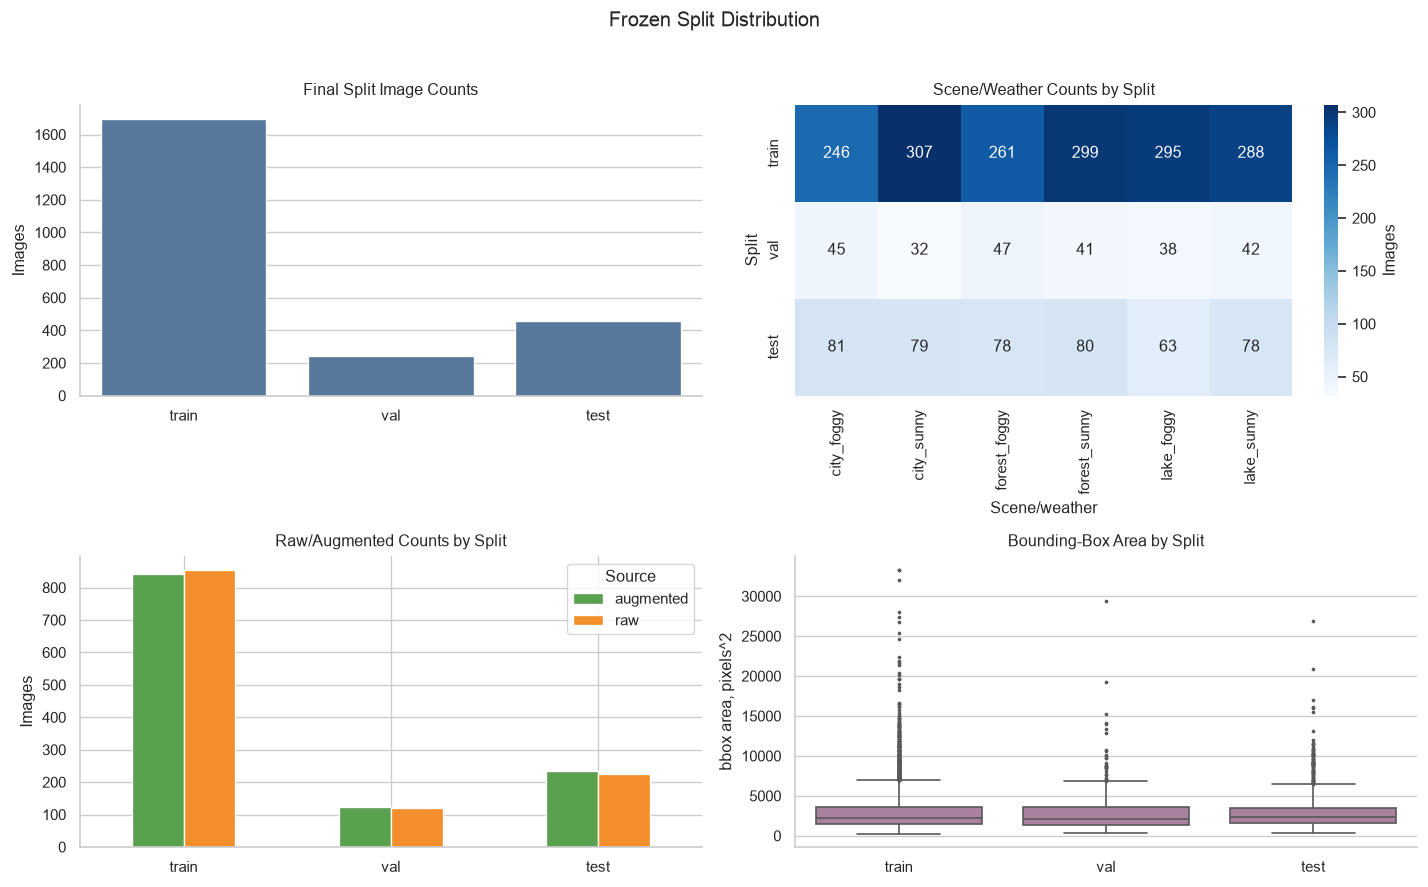

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))

sns.barplot(data=split_count_df, x="split", y="image_count", ax=axes[0, 0], color="#4C78A8", order=["train", "val", "test"])
axes[0, 0].set_title("Final Split Image Counts")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Images")

scene_counts = pd.crosstab(manifest_df["split"], manifest_df["scene_weather"]).reindex(["train", "val", "test"])
sns.heatmap(scene_counts, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Images"}, ax=axes[0, 1])
axes[0, 1].set_title("Scene/Weather Counts by Split")
axes[0, 1].set_xlabel("Scene/weather")
axes[0, 1].set_ylabel("Split")

source_counts = pd.crosstab(manifest_df["split"], manifest_df["raw_or_augmented"]).reindex(["train", "val", "test"])
source_counts.plot(kind="bar", stacked=False, ax=axes[1, 0], color=["#59A14F", "#F28E2B"])
axes[1, 0].set_title("Raw/Augmented Counts by Split")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Images")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(title="Source")

sns.boxplot(data=ann_with_split, x="split", y="area_px", order=["train", "val", "test"], ax=axes[1, 1], color="#B07AA1", fliersize=1.2)
axes[1, 1].set_title("Bounding-Box Area by Split")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("bbox area, pixels^2")

fig.suptitle("Frozen Split Distribution", y=1.02)
fig.tight_layout()
save_figure(fig, "split_distribution")
plt.show()

## 9. Final Recommendation

In [20]:
selected_train = selected_groups_df[selected_groups_df["split"] == "train"]["capture_pair"].tolist()
selected_val = selected_groups_df[selected_groups_df["split"] == "val"]["capture_pair"].tolist()
selected_test = selected_groups_df[selected_groups_df["split"] == "test"]["capture_pair"].tolist()

nearest_corr_desc = nearest_df["nearest_correlation"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
known_recovered = int(nearest_df["nearest_is_exact_filename_pair"].sum())
known_available = int(nearest_df["exact_filename_pair_exists"].sum())

final_md = f"""
**Selected strategy**

The frozen manifests use deterministic `capture_pair` grouping. Entire capture pairs are assigned to one split:

- Train capture pairs: {', '.join(selected_train)}
- Validation capture pairs: {', '.join(selected_val)}
- Test capture pairs: {', '.join(selected_test)}

This creates {int(split_count_df.loc[split_count_df['split'] == 'train', 'image_count'].iloc[0])} train images, {int(split_count_df.loc[split_count_df['split'] == 'val', 'image_count'].iloc[0])} validation images, and {int(split_count_df.loc[split_count_df['split'] == 'test', 'image_count'].iloc[0])} test images.

**Why this strategy was chosen**

- `capture_pair` has only ten values, each apparently associated with the two drone slots present in every image.
- The crop contact sheets show capture-pair-specific object appearance/scale regularities, supporting the hypothesis that capture pairs are source/target identity related.
- Exact filename raw/augmented pairs are rare ({known_available}), but all exact pairs stay together under capture-pair grouping.
- The split blocks all capture-pair overlap across train/validation/test, which is stricter than exact frame-key grouping or `scene_weather + capture_pair` grouping.

**Near-duplicate evidence**

- Every augmented image was matched to its nearest raw candidate using downsampled grayscale correlation.
- Known exact filename pairs recovered as nearest raw candidates: {known_recovered} / {known_available}.
- Nearest-neighbor correlation ranged from {nearest_corr_desc['min']:.3f} to {nearest_corr_desc['max']:.3f}, with median {nearest_corr_desc['50%']:.3f}.
- There is no single threshold that proves all nearest neighbors are true raw/augmented pairs, so nearest-neighbor results are used as leakage-risk evidence rather than automatic pairing labels.

**What the test set measures**

The test set measures interpolation over the same broad synthetic scene/weather families, but with held-out capture pairs. If `capture_pair` truly corresponds to drone/source identity, this is a stronger and more credible test than random image splitting.

**Remaining limitations**

- The exact meaning of `capture_pair` is not documented in the files.
- Neighboring `sequence_index` values may or may not be temporal neighbors.
- Lightweight grayscale similarity detects background/pixel similarity, not semantic equivalence.
- Stronger ground-truth grouping would require dataset generation metadata or official documentation describing captures, object identities, augmentation policy, and sequence semantics.
"""

display(Markdown(final_md))


**Selected strategy**

The frozen manifests use deterministic `capture_pair` grouping. Entire capture pairs are assigned to one split:

- Train capture pairs: 0_1, 4_5, 6_7, 10_11, 14_15, 16_17, 18_19
- Validation capture pairs: 8_9
- Test capture pairs: 2_3, 12_13

This creates 1696 train images, 245 validation images, and 459 test images.

**Why this strategy was chosen**

- `capture_pair` has only ten values, each apparently associated with the two drone slots present in every image.
- The crop contact sheets show capture-pair-specific object appearance/scale regularities, supporting the hypothesis that capture pairs are source/target identity related.
- Exact filename raw/augmented pairs are rare (44), but all exact pairs stay together under capture-pair grouping.
- The split blocks all capture-pair overlap across train/validation/test, which is stricter than exact frame-key grouping or `scene_weather + capture_pair` grouping.

**Near-duplicate evidence**

- Every augmented image was matched to its nearest raw candidate using downsampled grayscale correlation.
- Known exact filename pairs recovered as nearest raw candidates: 10 / 44.
- Nearest-neighbor correlation ranged from 0.712 to 0.988, with median 0.947.
- There is no single threshold that proves all nearest neighbors are true raw/augmented pairs, so nearest-neighbor results are used as leakage-risk evidence rather than automatic pairing labels.

**What the test set measures**

The test set measures interpolation over the same broad synthetic scene/weather families, but with held-out capture pairs. If `capture_pair` truly corresponds to drone/source identity, this is a stronger and more credible test than random image splitting.

**Remaining limitations**

- The exact meaning of `capture_pair` is not documented in the files.
- Neighboring `sequence_index` values may or may not be temporal neighbors.
- Lightweight grayscale similarity detects background/pixel similarity, not semantic equivalence.
- Stronger ground-truth grouping would require dataset generation metadata or official documentation describing captures, object identities, augmentation policy, and sequence semantics.
